# Step 12b (v2): qualitative dataset figures with live dataset statistics

**What changed from v1, per review:** every panel now carries the real full-scale statistic it illustrates (computed live in this notebook, not quoted); the drift figure sweeps the same caps as Test 1 (1 / 2 / 4 degrees); and exemplars are multiple objects chosen by distance.

**Outputs:**

- **Fig 7:** Knob 1 gallery, two objects (Car, Pedestrian) x [camera clean | camera noised | LiDAR clean | family A | family B], with dataset test accuracies under each condition in the panel titles
- **Fig 8a:** the Knob 2a mismatched pair
- **Fig 8b:** drift progression grid, three cars (near / mid / far) x four calibrations (true / 1 / 2 / 4 deg), per-panel consistency plus the dataset-mean consistency per column

**Needs:** `step7_kitti_objects.pt`, `step7_kitti_nets.pt`, and `KITTI_ROOT` for full-frame images. Run in `runs/full/`.


In [9]:
# ============ CONFIG + LOAD ============
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

SEED = 0
KITTI_ROOT = Path("D:\\Vstudio\\NIT MZ\\KITTI_ROOT")                  # EDIT ME if needed
JITTER_STD, CLUTTER_FRAC = 0.35, 0.60       # family A (audit values)
SECTOR_MAX_DEG, DROP_FRAC_B = 340.0, 0.90   # family B (audit values)
DRIFT_DEGS = [0.0, 1.0, 2.0, 4.0]           # matches Test 1 caps; translation = deg/10 m
OUT = Path("paper_figures"); OUT.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

blob = torch.load("step7_kitti_objects.pt", weights_only=False)
samples, calibs, CLASSES = blob["samples"], blob["calibs"], blob["classes"]
K = len(CLASSES); te_idx = blob["te_idx"]
te_crops  = torch.stack([torch.from_numpy(samples[i]["crop"].copy()).float().permute(2,0,1)/255.0
                         for i in te_idx])
te_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in te_idx])
y_te = torch.tensor([samples[i]["label"] for i in te_idx])
print(f"test objects: {len(te_idx)}  device: {DEVICE}")


test objects: 2247  device: cuda


In [10]:
# ============ NETS (for live accuracy labels) + CORRUPTIONS + GEOMETRY ============
class CropCNN(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.net  = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                  nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Linear(128, n_cls)
    def forward(self, x):
        return self.head(self.net(x))

class PointNetMini(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, n_cls))
    def forward(self, x):
        return self.head(self.mlp(x.transpose(1, 2)).max(dim=2).values)

sd = torch.load("step7_kitti_nets.pt", weights_only=False)
cam7 = CropCNN(K); cam7.load_state_dict(sd["cam"]); cam7.eval().to(DEVICE)
lid7 = PointNetMini(K); lid7.load_state_dict(sd["lid"]); lid7.eval().to(DEVICE)

@torch.no_grad()
def acc_of(model, x, bs=256):
    hits = 0
    for i in range(0, len(x), bs):
        hits += (model(x[i:i+bs].to(DEVICE)).argmax(1).cpu() == y_te[i:i+bs]).sum().item()
    return hits / len(x)

def corrupt_image_batch(crops, severity, rng):
    noise = torch.from_numpy(rng.normal(0, 0.30 * severity, crops.shape)).float()
    return (crops + noise).clamp(0, 1)

def corrupt_A_batch(points, severity, rng):
    pts = points.clone()
    pts[..., :3] += torch.from_numpy(rng.normal(0, JITTER_STD*severity, pts[...,:3].shape)).float()
    n_rep = int(CLUTTER_FRAC * severity * pts.shape[1])
    for b in range(pts.shape[0]):
        xyz = pts[b, :, :3].numpy()
        lo, hi = xyz.min(0), xyz.max(0)
        ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
        sel = rng.choice(pts.shape[1], n_rep, replace=False)
        pts[b, sel, :3] = torch.from_numpy(ctr - span/2 + rng.random((n_rep,3))*span).float()
        pts[b, sel, 3] = torch.from_numpy(rng.random(n_rep)).float()
    return pts

def _occlude_idx(xyz, severity, rng):
    ang = np.arctan2(xyz[:, 1], xyz[:, 0])
    a0 = rng.uniform(-np.pi, np.pi)
    half = np.deg2rad(SECTOR_MAX_DEG * severity) / 2
    diff = np.angle(np.exp(1j * (ang - a0)))
    keep = np.abs(diff) > half
    surv = np.where(keep)[0] if keep.sum() >= 3 else np.argsort(np.abs(diff))[-3:]
    n_drop = int(DROP_FRAC_B * severity * len(surv))
    if n_drop and len(surv) - n_drop >= 3:
        surv = rng.choice(surv, len(surv) - n_drop, replace=False)
    return surv

def corrupt_B_batch(points, severity, rng):
    pts = points.clone()
    for b in range(pts.shape[0]):
        surv = _occlude_idx(pts[b, :, :3].numpy(), severity, rng)
        idx = np.concatenate([surv, rng.choice(surv, pts.shape[1]-len(surv), replace=True)])
        pts[b] = pts[b][torch.from_numpy(idx)]
    return pts

def small_rotation(axis, angle):
    axis = np.asarray(axis, float); axis /= np.linalg.norm(axis)
    Kx = np.array([[0,-axis[2],axis[1]],[axis[2],0,-axis[0]],[-axis[1],axis[0],0]])
    return np.eye(3) + np.sin(angle)*Kx + (1-np.cos(angle))*(Kx@Kx)

def drift_T(Tr, deg, rng):
    if deg == 0: return Tr.copy()
    T = Tr.copy()
    dR = small_rotation(rng.normal(size=3), np.deg2rad(deg))
    d = rng.normal(size=3); d /= np.linalg.norm(d)
    T[:3,:3] = dR @ T[:3,:3]; T[:3,3] = dR @ T[:3,3] + d * (deg / 10.0)
    return T

def project(pts_velo, calib, Tr):
    hom = np.hstack([pts_velo, np.ones((len(pts_velo),1))])
    rect = (calib["R0_rect"] @ Tr @ hom.T).T[:, :3]
    proj = (calib["P2"] @ np.hstack([rect, np.ones((len(rect),1))]).T).T
    depth = proj[:, 2]
    return proj[:, :2] / np.clip(depth[:, None], 1e-6, None), depth

def consistency(pv, box, calib, Tr):
    uv, depth = project(pv, calib, Tr)
    x1, y1, x2, y2 = box
    inside = (depth>0)&(uv[:,0]>=x1)&(uv[:,0]<=x2)&(uv[:,1]>=y1)&(uv[:,1]<=y2)
    return float(inside.mean()), uv, inside

print("nets + utilities ready")


nets + utilities ready


In [11]:
# ============ LIVE DATASET STATISTICS (the labels) ============
g = np.random.default_rng(SEED + 60)
stat = {}
stat["cam_clean"] = acc_of(cam7, te_crops)
stat["cam_s05"]   = acc_of(cam7, corrupt_image_batch(te_crops, 0.5, g))
stat["cam_s10"]   = acc_of(cam7, corrupt_image_batch(te_crops, 1.0, g))
stat["lid_clean"] = acc_of(lid7, te_points)
stat["lid_A"]     = acc_of(lid7, corrupt_A_batch(te_points, 1.0, g))
stat["lid_B"]     = acc_of(lid7, corrupt_B_batch(te_points, 1.0, g))
print("dataset test accuracies:")
print(f"  camera  clean {stat['cam_clean']:.3f}  sev0.5 {stat['cam_s05']:.3f}  sev1.0 {stat['cam_s10']:.3f}")
print(f"  LiDAR   clean {stat['lid_clean']:.3f}  famA(1.0) {stat['lid_A']:.3f}  famB(1.0) {stat['lid_B']:.3f}")

# dataset-mean projection consistency per drift level (all test objects, 2 draws)
mean_cons = {}
for deg in DRIFT_DEGS:
    vals = []
    for draw in range(1 if deg == 0 else 2):
        r = np.random.default_rng(SEED + 70 + int(deg*10) + draw)
        Ts = {f: drift_T(calibs[f]["Tr_velo_cam"], deg, r)
              for f in {samples[i]["frame_id"] for i in te_idx}}
        vals += [consistency(samples[i]["pts_velo_raw"].astype(float), samples[i]["box2d"],
                             calibs[samples[i]["frame_id"]], Ts[samples[i]["frame_id"]])[0]
                 for i in te_idx]
    mean_cons[deg] = float(np.mean(vals))
print("dataset-mean projection consistency per drift:",
      {d: round(v, 3) for d, v in mean_cons.items()})


dataset test accuracies:
  camera  clean 0.887  sev0.5 0.339  sev1.0 0.279
  LiDAR   clean 0.998  famA(1.0) 0.438  famB(1.0) 0.775
dataset-mean projection consistency per drift: {0.0: 0.944, 1.0: 0.8, 2.0: 0.581, 4.0: 0.306}


## Fig 7: Knob 1 gallery, two objects, dataset accuracies in the titles

saved fig7


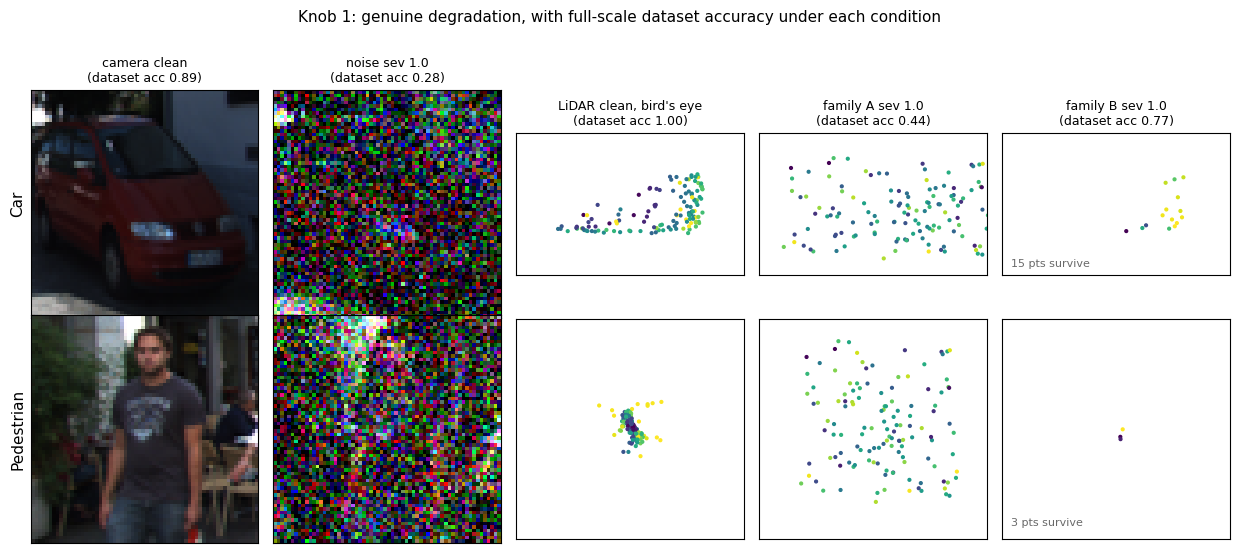

In [12]:
# ============ FIG 7 ============
def pick(cls_name, rank=0):
    cand = [i for i in te_idx if CLASSES[samples[i]["label"]] == cls_name]
    cand.sort(key=lambda i: -len(samples[i]["pts_velo_raw"]))
    return cand[min(rank, len(cand)-1)]

rows = [("Car", pick("Car")), ("Pedestrian", pick("Pedestrian"))]
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 5, figsize=(12.5, 5.4))
col_titles = [
    f"camera clean\n(dataset acc {stat['cam_clean']:.2f})",
    f"noise sev 1.0\n(dataset acc {stat['cam_s10']:.2f})",
    f"LiDAR clean, bird's eye\n(dataset acc {stat['lid_clean']:.2f})",
    f"family A sev 1.0\n(dataset acc {stat['lid_A']:.2f})",
    f"family B sev 1.0\n(dataset acc {stat['lid_B']:.2f})"]

for r, (cls, idx) in enumerate(rows):
    s = samples[idx]
    crop, cn = s["crop"], s["points"].astype(np.float64)
    axes[r][0].imshow(crop)
    axes[r][1].imshow(np.clip(crop/255.0 + rng.normal(0, 0.30, crop.shape), 0, 1))
    pA = corrupt_A_batch(torch.from_numpy(s["points"]).float()[None], 1.0,
                         np.random.default_rng(SEED+2))[0].numpy()
    survB = _occlude_idx(cn[:, :3], 1.0, np.random.default_rng(SEED+3))
    pB = cn[survB]
    for c, pts in [(2, cn), (3, pA), (4, pB)]:
        ax = axes[r][c]
        ax.scatter(pts[:, 0], pts[:, 2], s=4, c=pts[:, 1], cmap="viridis")
        ax.set_aspect("equal")
        ax.set_xlim(cn[:,0].min()-1.2, cn[:,0].max()+1.2)
        ax.set_ylim(cn[:,2].min()-1.2, cn[:,2].max()+1.2)
        if c == 4:
            ax.annotate(f"{len(pB)} pts survive", (0.04, 0.06),
                        xycoords="axes fraction", fontsize=8, color="dimgray")
    for c in range(5):
        axes[r][c].set_xticks([]); axes[r][c].set_yticks([])
        if r == 0: axes[r][c].set_title(col_titles[c], fontsize=9)
    axes[r][0].set_ylabel(cls, fontsize=11)
plt.suptitle("Knob 1: genuine degradation, with full-scale dataset accuracy under each condition",
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(OUT/"fig7_knob1_gallery.pdf", bbox_inches="tight")
fig.savefig(OUT/"fig7_knob1_gallery.png", dpi=300, bbox_inches="tight")
print("saved fig7"); plt.show()


## Fig 8a: the Knob 2a mismatched pair

saved fig8a


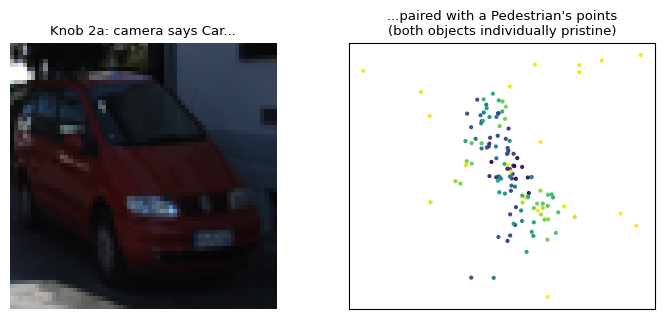

In [13]:
# ============ FIG 8A ============
s_car, s_ped = samples[pick("Car")], samples[pick("Pedestrian")]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.4, 3.2))
a1.imshow(s_car["crop"]); a1.axis("off")
a1.set_title("Knob 2a: camera says Car...", fontsize=9.5)
cp = s_ped["points"].astype(np.float64)
a2.scatter(cp[:, 0], cp[:, 2], s=4, c=cp[:, 1], cmap="viridis")
a2.set_aspect("equal"); a2.set_xticks([]); a2.set_yticks([])
a2.set_title("...paired with a Pedestrian's points\n(both objects individually pristine)", fontsize=9.5)
plt.tight_layout()
fig.savefig(OUT/"fig8a_swap_pair.pdf", bbox_inches="tight")
fig.savefig(OUT/"fig8a_swap_pair.png", dpi=300, bbox_inches="tight")
print("saved fig8a"); plt.show()


## Fig 8b: drift progression grid (near / mid / far x true / 1 / 2 / 4 degrees)

Row labels carry each car's measured range; column headers carry the **dataset-mean** consistency over all test objects at that drift. The per-panel titles are that single object's consistency. Together the grid shows the effect existing at 1 degree, matching the audit at 2, and growing with both drift and distance.


saved fig8b


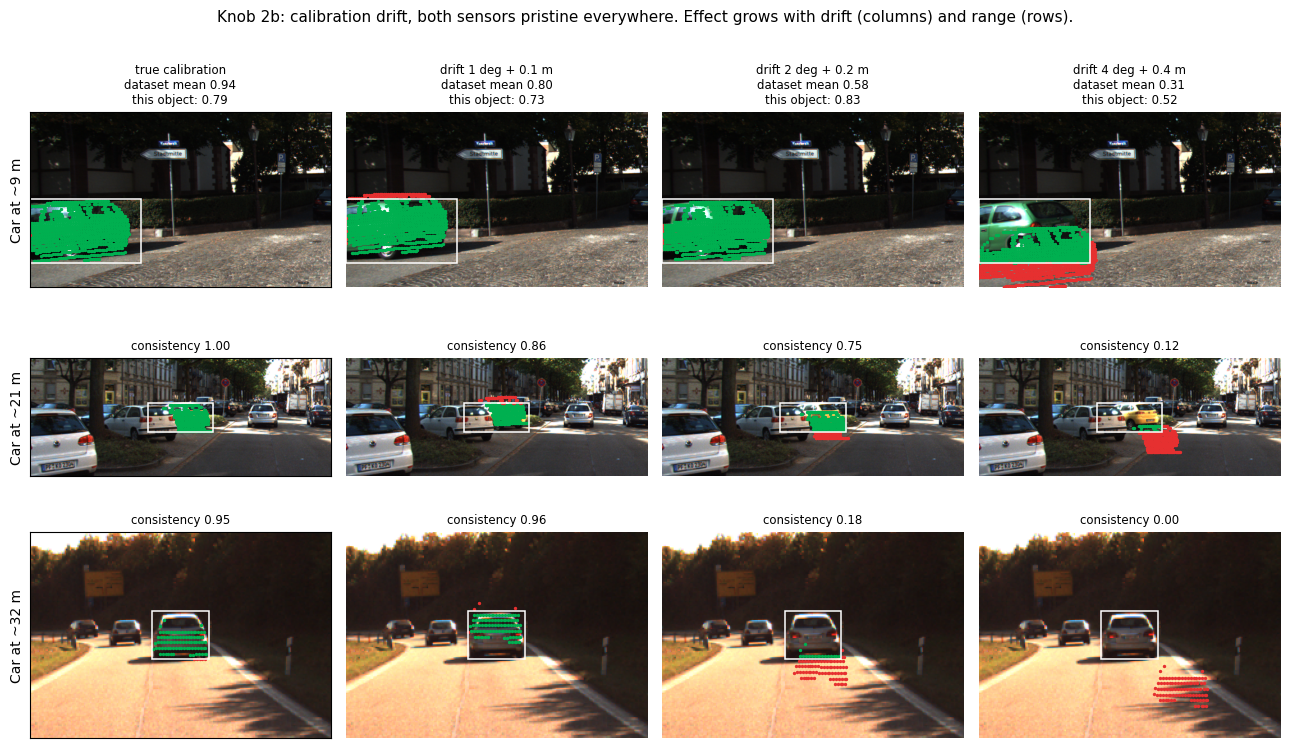

In [14]:
# ============ FIG 8B ============
cars = [i for i in te_idx if CLASSES[samples[i]["label"]] == "Car"
        and len(samples[i]["pts_velo_raw"]) >= 60]
depth = {i: float(samples[i]["pts_velo_raw"][:, 0].mean()) for i in cars}
cars_sorted = sorted(cars, key=lambda i: depth[i])
picks = [cars_sorted[int(q * (len(cars_sorted)-1))] for q in (0.10, 0.55, 0.90)]
labels = [f"Car at ~{depth[i]:.0f} m" for i in picks]

fig, axes = plt.subplots(3, 4, figsize=(13.0, 7.6))
for r, (idx, lab) in enumerate(zip(picks, labels)):
    s = samples[idx]
    img = np.asarray(Image.open(KITTI_ROOT/f"training/image_2/{s['frame_id']}.png").convert("RGB"))
    calib, pv, box = calibs[s["frame_id"]], s["pts_velo_raw"].astype(float), s["box2d"]
    x1, y1, x2, y2 = box
    for c, deg in enumerate(DRIFT_DEGS):
        ax = axes[r][c]
        T = drift_T(calib["Tr_velo_cam"], deg, np.random.default_rng(SEED + 80 + int(deg*10)))
        cons, uv, inside = consistency(pv, box, calib, T)
        ax.imshow(img)
        ax.scatter(uv[inside, 0], uv[inside, 1], s=2.0, c="#00b050")
        ax.scatter(uv[~inside, 0], uv[~inside, 1], s=2.0, c="#e63030")
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="white", lw=1.1))
        pad_x, pad_y = 1.6*(x2-x1) + 25, 1.2*(y2-y1) + 18
        ax.set_xlim(max(0, x1-pad_x), min(img.shape[1], x2+pad_x))
        ax.set_ylim(min(img.shape[0], y2+pad_y), max(0, y1-pad_y))
        ax.set_title(f"consistency {cons:.2f}", fontsize=8.5)
        ax.axis("off")
        if r == 0:
            hdr = "true calibration" if deg == 0 else f"drift {deg:.0f} deg + {deg/10:.1f} m"
            ax.set_title(f"{hdr}\ndataset mean {mean_cons[deg]:.2f}\nthis object: {cons:.2f}",
                         fontsize=8.5)
    axes[r][0].axis("on")
    axes[r][0].set_xticks([]); axes[r][0].set_yticks([])
    axes[r][0].set_ylabel(lab, fontsize=10)
plt.suptitle("Knob 2b: calibration drift, both sensors pristine everywhere. "
             "Effect grows with drift (columns) and range (rows).", fontsize=11, y=1.0)
plt.tight_layout()
fig.savefig(OUT/"fig8b_drift_grid.pdf", bbox_inches="tight")
fig.savefig(OUT/"fig8b_drift_grid.png", dpi=300, bbox_inches="tight")
print("saved fig8b"); plt.show()


## Caption ammunition (numbers this notebook just computed)

Use the printed dataset statistics directly in the captions: camera accuracy clean vs noised, LiDAR accuracy under each family, and the mean-consistency-per-drift row. Every number in these figures is now full-scale, live-computed, and regenerates with the notebook. If an exemplar is unphotogenic, adjust `rank=` (Fig 7/8a) or the quantile tuple (Fig 8b).


In [15]:
from pathlib import Path
for p in Path(r"D:\Vstudio\NIT MZ").rglob("image_2"):
    print(p)

D:\Vstudio\NIT MZ\KITTI_ROOT\training\image_2
